In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# PCA fundamentals

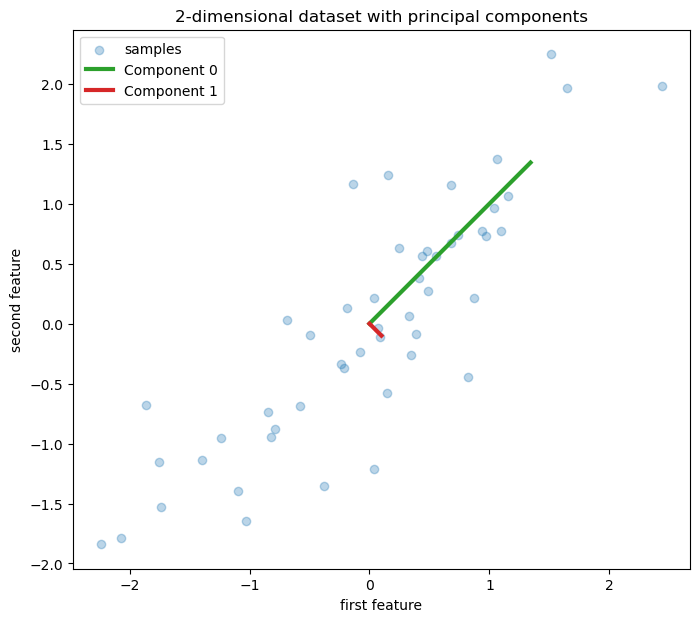

In [2]:
X = np.random.multivariate_normal(mean=[0, 0], cov= [[3, 3], [3, 4]], size=50)
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2).fit(X)

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label="samples")
for i, (comp, var) in enumerate(zip(pca.components_, pca.explained_variance_)):
    comp = comp * var  # scale component by its variance explanation power
    plt.plot(
        [0, comp[0]],
        [0, comp[1]],
        label=f"Component {i}",
        linewidth=3,
        color=f"C{i + 2}",
    )
plt.gca().set(
    aspect="equal",
    title="2-dimensional dataset with principal components",
    xlabel="first feature",
    ylabel="second feature",
)
plt.legend()
plt.show()

In [3]:
pca.components_

array([[ 0.70710678,  0.70710678],
       [ 0.70710678, -0.70710678]])

In [4]:
print('Original vectors')
print(X[:4].round(2))
print("")
print('Projection matrix')
print(pca.components_.round(2))
print("")
print('Projection result')
print((X[:4] @ pca.components_).round(2))

Original vectors
[[ 0.68  1.15]
 [-0.58 -0.68]
 [ 0.68  0.67]
 [-1.74 -1.53]]

Projection matrix
[[ 0.71  0.71]
 [ 0.71 -0.71]]

Projection result
[[ 1.3  -0.33]
 [-0.89  0.07]
 [ 0.95  0.01]
 [-2.31 -0.15]]


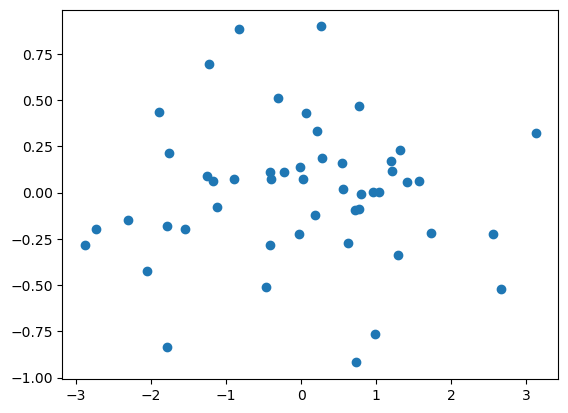

In [5]:
projected = X @ pca.components_

plt.scatter(projected[:, 0], projected[:, 1])
plt.show()

9.8586030776932e-16


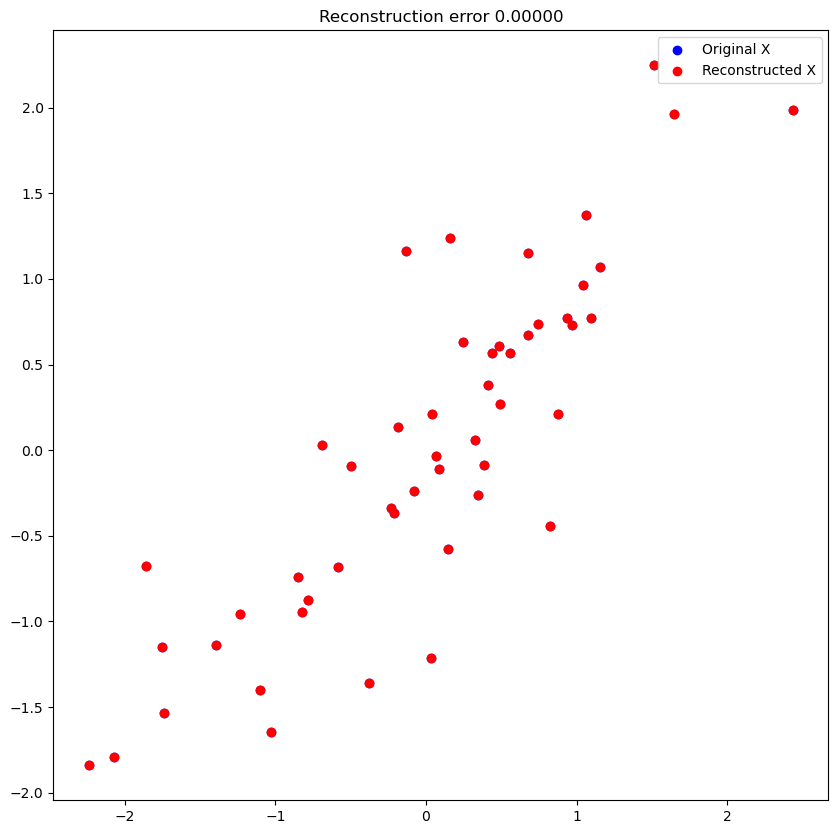

In [6]:
X_reconstructred = projected @ pca.components_.T

error = np.linalg.norm(X - X_reconstructred)
print(error)
plt.figure(figsize=(10,10))
plt.title(f'Reconstruction error {error:.5f}')
plt.scatter(X[:, 0], X[:, 1], label='Original X', color='blue')
plt.scatter(X_reconstructred[:, 0], X_reconstructred[:, 1], label='Reconstructed X', color='red')
plt.legend()
plt.show()

9.647838495571795


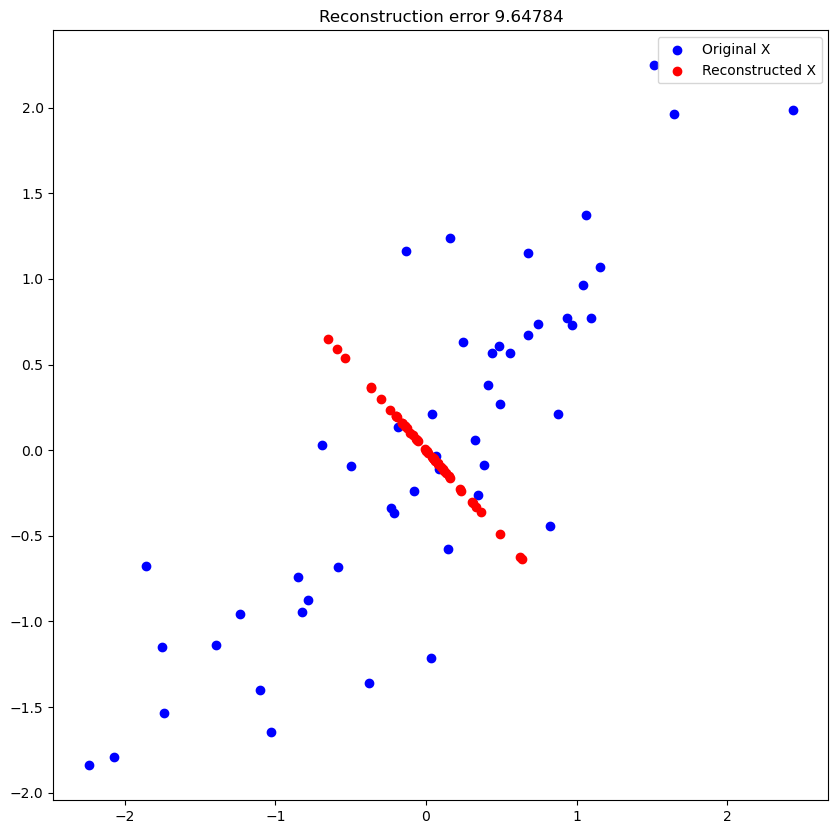

In [7]:
reduced_projection = pca.components_[:, [1]]

projected = X @ reduced_projection
X_reconstructred = projected @ reduced_projection.T

error = np.linalg.norm(X - X_reconstructred)
print(error)
plt.figure(figsize=(10,10))
plt.title(f'Reconstruction error {error:.5f}')
plt.scatter(X[:, 0], X[:, 1], label='Original X', color='blue')
plt.scatter(X_reconstructred[:, 0], X_reconstructred[:, 1], label='Reconstructed X', color='red')
plt.legend()
plt.show()


2.6304395760714545


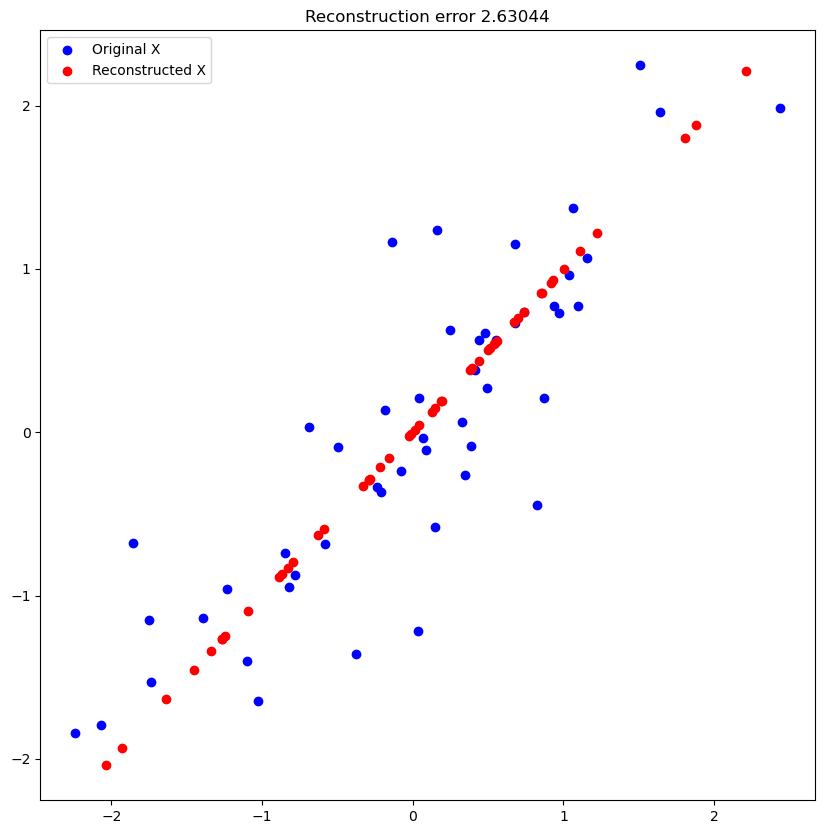

In [8]:
reduced_projection = pca.components_[:, [0]]

projected = X @ reduced_projection
X_reconstructred = projected @ reduced_projection.T

error = np.linalg.norm(X - X_reconstructred)
print(error)
plt.figure(figsize=(10,10))
plt.title(f'Reconstruction error {error:.5f}')
plt.scatter(X[:, 0], X[:, 1], label='Original X', color='blue')
plt.scatter(X_reconstructred[:, 0], X_reconstructred[:, 1], label='Reconstructed X', color='red')
plt.legend()
plt.show()


In [9]:
from scipy.optimize import minimize, least_squares

In [10]:
def loss(coefs, x):
    coefs = coefs.reshape(-1, 1)
    projected = x @ coefs
    X_reconstructred = projected @ coefs.T

    error = np.linalg.norm(X - X_reconstructred)

    norm_error = np.linalg.norm(coefs)
    return error + norm_error

def fit_regression(X):
    params = np.array([0.5, 0.5])
    best_params = least_squares(loss, params, args=(X,))
    return best_params


[0.70205307 0.70205307]


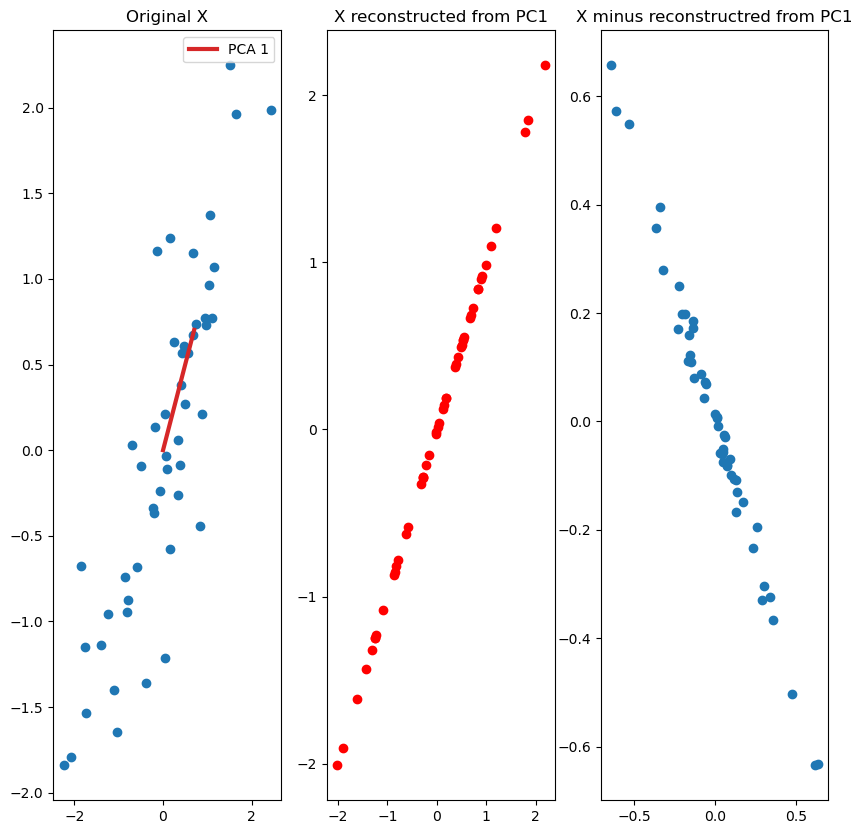

In [11]:
pca_1_line = fit_regression(X)
print(pca_1_line.x)

first_component = pca_1_line.x.reshape(-1, 1)

first_projected = X @ first_component

first_X_reconstructred = first_projected @ first_component.T

second_X = X - first_X_reconstructred

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.title('Original X')
plt.scatter(X[:, 0], X[:, 1])

plt.plot(
        [0, pca_1_line.x[0]],
        [0, pca_1_line.x[1]],
        label=f"PCA 1",
        linewidth=3,
        color=f"C{i + 2}",
    )
plt.legend()

plt.subplot(1, 3, 2)
plt.title('X reconstructed from PC1')
plt.scatter(first_X_reconstructred[:, 0], first_X_reconstructred[:, 1], label='X reconstructed from PC1', color='red')
plt.subplot(1, 3, 3)
plt.title('X minus reconstructred from PC1')
plt.scatter(second_X[:, 0], second_X[:, 1])
plt.show()

C:\Users\mazurenko\AppData\Local\Temp\ipykernel_22180\496707115.py:21: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1, figsize=(4, 3))


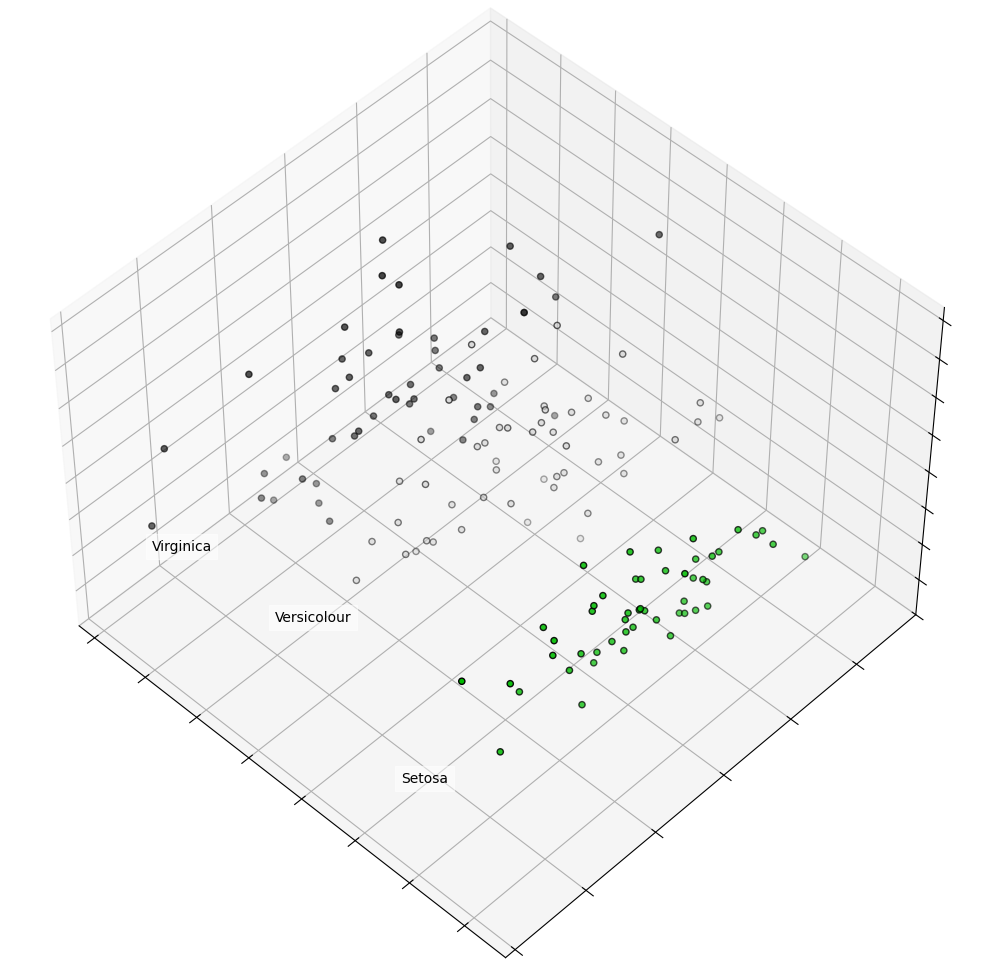

In [12]:
# Code source: Gaël Varoquaux
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt


from sklearn import decomposition
from sklearn import datasets

# unused but required import for doing 3d projections with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401

np.random.seed(5)

plt.figure(figsize=(10,10))
iris = datasets.load_iris()
X = iris.data
y = iris.target

fig = plt.figure(1, figsize=(4, 3))
plt.clf()

ax = fig.add_subplot(111, projection="3d", elev=48, azim=134)
ax.set_position([0, 0, 0.95, 1])


plt.cla()
pca = decomposition.PCA(n_components=3)
pca.fit(X)
X = pca.transform(X)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 0].mean(),
        X[y == label, 1].mean() + 1.5,
        X[y == label, 2].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.5, edgecolor="w", facecolor="w"),
    )
# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(float)
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap=plt.cm.nipy_spectral, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

In [13]:
from plotly import express as px

px.bar(pca.components_[0], width=500, height=400)

In [14]:
px.bar(pca.components_[1], width=500, height=400)

In [15]:
px.bar(pca.components_[2], width=500, height=400)

# PCA in Sklearn

In [16]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, parser='auto')

In [17]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [18]:
y[50000]

'3'

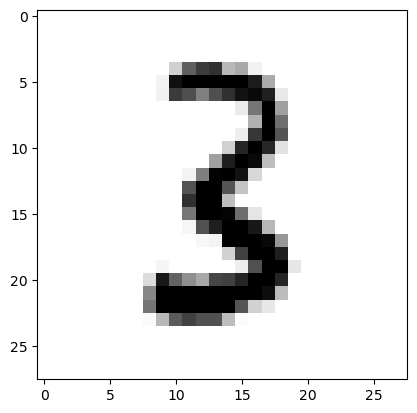

In [19]:
plt.imshow(np.array(X)[50000].reshape(28, 28), cmap=plt.cm.gray_r);

In [20]:
X.shape

(70000, 784)

In [21]:
# X = StandardScaler().fit_transform(X)
pca = PCA()
pca.fit(X)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.9) + 1
d

np.int64(87)

In [ ]:
pca.explained_variance_ratio_[:3]

array([0.09746116, 0.07155445, 0.06149531])

In [23]:
d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(154)

In [27]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
cumsum

array([0.09746116, 0.16901561, 0.23051091, 0.28454476, 0.3334341 ,
       0.37648637, 0.40926898, 0.4381654 , 0.46574904, 0.48917044,
       0.51023733, 0.53061286, 0.5476835 , 0.5646237 , 0.58045752,
       0.59532097, 0.60851456, 0.6213047 , 0.63317742, 0.64470679,
       0.65536719, 0.66546513, 0.67505665, 0.684153  , 0.69298586,
       0.70137405, 0.70947236, 0.71732954, 0.72473217, 0.73163231,
       0.73819375, 0.74464845, 0.75065664, 0.75651276, 0.7621803 ,
       0.767615  , 0.77266217, 0.77753297, 0.78232252, 0.78699846,
       0.79154214, 0.79599132, 0.80017349, 0.80413513, 0.8079722 ,
       0.81173005, 0.81534432, 0.81883456, 0.82222188, 0.82541884,
       0.82858738, 0.83168883, 0.83465363, 0.83752465, 0.84034978,
       0.84304401, 0.84572793, 0.84829303, 0.85082471, 0.85327119,
       0.85566821, 0.85805402, 0.86034636, 0.86255585, 0.86468645,
       0.86674963, 0.86877744, 0.87072779, 0.8726425 , 0.87452799,
       0.87639775, 0.8781988 , 0.87996667, 0.88170025, 0.88334

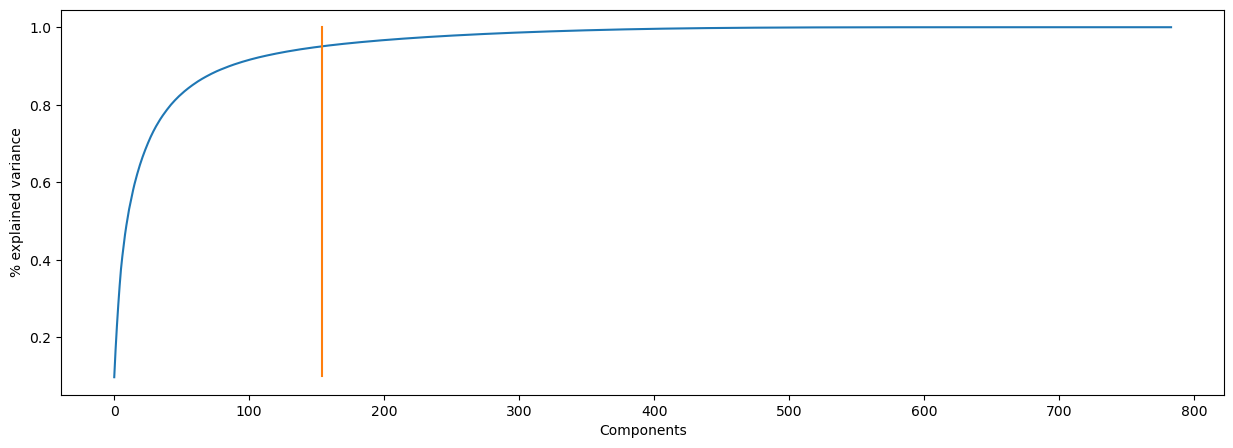

In [25]:
plt.figure(figsize=(15, 5))
plt.plot(cumsum)
plt.plot([d, d], [0.1, 1])
plt.xlabel("Components")
plt.ylabel("% explained variance")
plt.show()

# Visualization

In [28]:
idx = np.random.randint(X.shape[0], size=1000)
X_sample = np.array(X)[idx,:]
y_sample = np.array(y)[idx]

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_sample)

X_sample.shape, X.shape, y_sample.shape, y.shape

((1000, 784), (70000, 784), (1000,), (70000,))

In [29]:
X_reduced.shape

(1000, 2)

In [30]:
px.scatter(
    x=X_reduced[:, 0],
    y=X_reduced[:, 1],
    color=y_sample.astype(int),
)

# UMAP

In [ ]:
#!pip install umap-learn

In [32]:
import umap

reducer = umap.UMAP()

c:\Users\mazurenko\.conda\envs\otus-ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [33]:
X.shape

(70000, 784)

In [34]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
X.loc[0]

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Name: 0, Length: 784, dtype: int64

In [36]:
embedding = reducer.fit_transform(X)
embedding.shape

(70000, 2)

In [37]:
embedding

array([[ 3.8378747,  4.424707 ],
       [16.191698 ,  5.0410633],
       [-0.6226957, 13.204137 ],
       ...,
       [-3.0322547, 12.393215 ],
       [ 2.861014 ,  2.7458816],
       [11.647055 ,  4.8390975]], shape=(70000, 2), dtype=float32)

In [38]:
px.scatter(
    x=embedding[:, 0],
    y=embedding[:, 1],
    color=y.astype(int),
)